In [39]:
import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

RANDOM_SEED = 694973

import sklearn
print("sklearn: "+sklearn.__version__)

sklearn: 1.9.0


In [40]:
df=pd.read_csv('nba_api_code/nba_shots_pbp.csv')
df.head(5)

,gameId,actionNumber,clock,period,teamId,teamTricode,personId,playerName,playerNameI,xLegacy,...,shotValue,actionId,GAME_ID,homeTeamId,homeTeamTricode,awayTeamId,awayTeamTricode,defTeamId,defTeamTricode,SEASON
0,22100001,7,PT11M42.00S,1,1610612749,MIL,1628960,Allen,G. Allen,-164,...,3,3,22100001,1.610613e+09,MIL,1.610613e+09,BKN,NaN,NaN,2021-22
1,22100001,15,PT11M13.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,0,...,3,10,22100001,1.610613e+09,MIL,1.610613e+09,BKN,NaN,NaN,2021-22
2,22100001,18,PT11M01.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,5,...,2,12,22100001,1.610613e+09,MIL,1.610613e+09,BKN,NaN,NaN,2021-22
3,22100001,20,PT10M47.00S,1,1610612751,BKN,1629651,Claxton,N. Claxton,1,...,2,14,22100001,1.610613e+09,MIL,1.610613e+09,BKN,NaN,NaN,2021-22
4,22100001,22,PT10M31.00S,1,1610612749,MIL,203507,Antetokounmpo,G. Antetokounmpo,15,...,2,15,22100001,1.610613e+09,MIL,1.610613e+09,BKN,NaN,NaN,2021-22


In [41]:
df.shape

(1089418, 32)

In [42]:
# recode target variable to be 0 and 1
df['is_made'] = np.where(df['shotResult']=='Made',1,0)

In [43]:
df['distance'] = np.sqrt((df["xLegacy"]/10)**2 + (df["yLegacy"]/10)**2)
df['angle'] = np.degrees(np.arctan2(df['xLegacy'].abs(), df['yLegacy']))

df = df.loc[df['angle']<=120]
df = df.loc[df['distance']<=48] # one foot past halfway
round(df[['distance', 'angle']].describe(), 2)

,distance,angle
count,1079868.00,1079868.00
mean,14.25,40.49
std,10.45,28.18
min,0.00,0.00
25%,3.30,17.33
50%,13.39,36.50
75%,25.13,61.29
max,47.98,119.98


<Axes: >

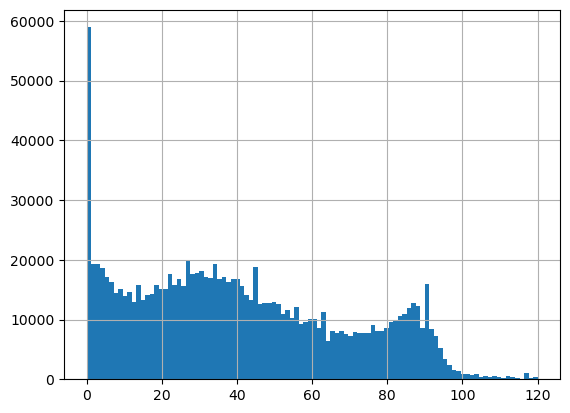

In [44]:
df['angle'].hist(bins=100)

<Axes: >

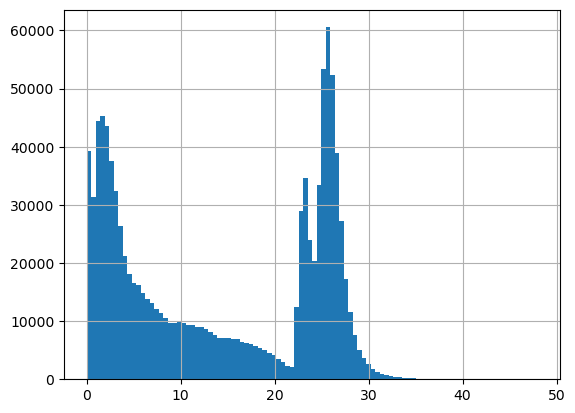

In [45]:
df['distance'].hist(bins=100)

In [46]:
# codify shot type
layups = ['Tip Layup Shot','Driving Layup Shot','Running Layup Shot','Cutting Layup Shot','Driving Reverse Layup Shot','Layup Shot',
          'Driving Finger Roll Layup Shot','Running Reverse Layup Shot','Running Finger Roll Layup Shot','Alley Oop Layup shot','Putback Layup Shot',
          'Reverse Layup Shot','Finger Roll Layup Shot','Cutting Finger Roll Layup Shot','Running Alley Oop Layup Shot']
jumper = ['Jump Shot','Driving Floating Bank Jump Shot','Driving Floating Jump Shot','Fadeaway Jump Shot', 'Step Back Jump shot','Running Jump Shot',
          'Pullup Jump shot','Floating Jump shot','Running Pull-Up Jump Shot','Turnaround Fadeaway Bank Jump Shot', 'Jump Bank Shot', 'Turnaround Jump Shot','Step Back Bank Jump Shot',
          'Turnaround Fadeaway shot','Turnaround Bank shot','Fadeaway Bank shot'
          ]
dunk = ['Running Dunk Shot', 'Cutting Dunk Shot','Driving Dunk Shot','Putback Dunk Shot','Running Alley Oop Dunk Shot', 'Tip Dunk Shot', 'Dunk Shot',
        'Reverse Dunk Shot', 'Alley Oop Dunk Shot','Running Reverse Dunk Shot','Driving Reverse Dunk Shot',
        ]
hook = ['Hook Shot','Turnaround Bank Hook Shot','Turnaround Hook Shot', 'Driving Hook Shot', 'Hook Bank Shot','Driving Bank Hook Shot',]

df['shot_type'] = np.where(df['subType'].isin(layups),"LAYUP",'OTH')
df['shot_type'] = np.where(df['subType'].isin(jumper),"JUMPER",df['shot_type'])
df['shot_type'] = np.where(df['subType'].isin(dunk),"DUNK",df['shot_type'])
df['shot_type'] = np.where(df['subType'].isin(hook),"HOOK",df['shot_type'])
print(pd.unique(df['shot_type']))

<ArrowStringArray>
['JUMPER', 'DUNK', 'HOOK', 'LAYUP']
Length: 4, dtype: str


In [47]:
sub = df[['distance','angle','is_made','shot_type']].reset_index(drop=True)
X = sub[['distance','angle']].values
y = sub['is_made'].values
idx = np.arange(len(y))
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(X, y, idx, test_size=0.33, random_state=RANDOM_SEED)
sub['is_train'] = sub.index.isin(idx_train).astype(int)
sub = sub.reset_index(drop=True)
sub.head()

,distance,angle,is_made,shot_type,is_train
0,26.645075,37.988142,0,JUMPER,1
1,26.300000,0.000000,0,JUMPER,1
2,14.708501,1.948085,0,JUMPER,1
3,0.412311,14.036243,1,DUNK,1
4,10.507616,8.207216,0,HOOK,1


In [48]:
sub.shape

(1079868, 5)

In [49]:
scaler = MinMaxScaler()
X_train_mm = scaler.fit_transform(X_train)
X_test_mm = scaler.transform(X_test)

idx = np.concatenate([idx_train, idx_test])
mm = np.vstack([X_train_mm, X_test_mm])

sort_order = np.argsort(idx)
sub[['distance_mm', 'angle_mm']] = mm[sort_order]

In [50]:
sub.head()

,distance,angle,is_made,shot_type,is_train,distance_mm,angle_mm
0,26.645075,37.988142,0,JUMPER,1,0.555379,0.316616
1,26.300000,0.000000,0,JUMPER,1,0.548187,0.000000
2,14.708501,1.948085,0,JUMPER,1,0.306578,0.016237
3,0.412311,14.036243,1,DUNK,1,0.008594,0.116987
4,10.507616,8.207216,0,HOOK,1,0.219017,0.068404


In [51]:
sub.tail()

,distance,angle,is_made,shot_type,is_train,distance_mm,angle_mm
1079863,15.597436,40.840358,0,JUMPER,0,0.325107,0.340388
1079864,8.487638,55.561011,0,LAYUP,1,0.176913,0.463079
1079865,0.000000,0.000000,0,LAYUP,0,0.000000,0.000000
1079866,3.573514,17.927920,1,DUNK,1,0.074485,0.149422
1079867,8.321658,94.134671,0,LAYUP,0,0.173453,0.784576


In [52]:
sub.to_csv('shot_probs_data.csv',index=False)

In [53]:
joblib.dump(scaler, 'scaler_da.pkl')

['scaler_da.pkl']